# Wallmart 데이터 분석

## 프로젝트 개요
[Kaggle의 Wallmart 데이터 셋](https://www.kaggle.com/datasets/devarajv88/walmart-sales-dataset) 분석 프로젝트입니다. 데이터 전처리, 탐색적 데이터 분석(EDA)을 통한 데이터의 분포를 확인하고, VIP 고객 도출 및 지역별 구매 고객 특징을 파악하여 마케팅 전략을 도출합니다.
이 프로젝트의 목표는 주어진 데이터의 분포를 분석하여 주요 특징을 도출하고, 이를 바탕으로 마케팅 전략을 제시하는 것입니다.

## 데이터 설명
- 데이터 출처: [Kaggle의 Wallmart 데이터 셋](https://www.kaggle.com/datasets/devarajv88/walmart-sales-dataset) 
- 데이터 상세: 약 55만개의 사용자 거래 내역과 10개의 특징(550068, 10)
  - `User_ID`: User ID
  - `Product_ID`: Product ID
  - `Gender`: Sex of User
  - `Age`: Age in bins
  - `Occupation`: Occupation(Masked)
  - `City_Category`: Category of the City (A,B,C)
  - `StayInCurrentCityYears`: Number of years stay in current city
  - `Marital_Status`: Marital Status
  - `ProductCategory`: Product Category (Masked)
  - `Purchase`: Purchase Amount


# 데이터 불러오기

In [ ]:
import matplotlib.pyplot as plt


In [19]:
import pandas as pd

df = pd.read_csv('data/walmart.csv')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


# EDA

In [20]:
# 전체 데이터가 몇 개 있는것인가?  
df.shape

(550068, 10)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


결측치는 확인되지 않았습니다.

총 550,068 건의 데이터를 대상으로 분석을 수행했습니다.

In [22]:
# 몇명의 고객 정보인가?
# User-id 갯수
df['User_ID'].unique()   # Array Type
len(df['User_ID'].unique())

5891

총 5,891명의 사용자 거래 내역이 담겨 있습니다.

In [23]:
# 고객의 분포

# df.groupby(['Gender', 'Age']).size()

df.groupby(['Age']).size()

# df.groupby(['Gender']).size()



Age
0-17      15102
18-25     99660
26-35    219587
36-45    110013
46-50     45701
51-55     38501
55+       21504
dtype: int64

26~35세 연령대의 고객이 가장 많이 방문했습니다.  : 36-45, 18-25 순 <br>
남자가 여자 대비 3배정도 많음

In [24]:
# Age Group List 추출

# age_group = df.groupby(['Age']).indices.keys()
# age_group = list(age_group)

age_group = df['Age'].unique().tolist()
age_group
# age_group = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']


['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25']

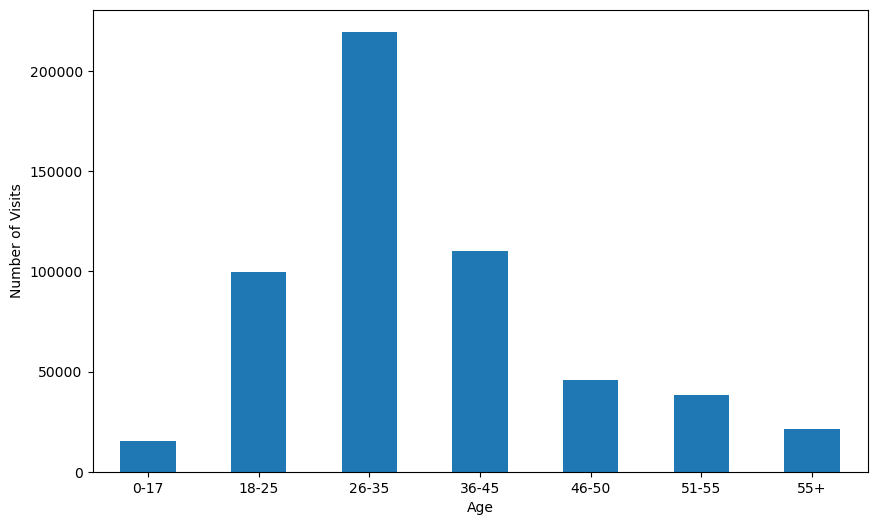

In [25]:
# 연령별 고객수 Bar Chart
plt.figure(figsize=[10,6])

bar_data = df.groupby(['Age']).size()
# plt.bar(x=bar_data.index, height=bar_data)

bar_data.plot(kind='bar')
# X축 레이블을 수평(horizontal)으로 설정
plt.xticks(rotation='horizontal') # 또는 rotation=0
plt.ylabel("Number of Visits") # 또는 rotation=0
plt.show()


26~35세 연령대가 22만명 이상으로 경제활동이 활발한 소비 주도층이 주요 타깃 고객군일 가능성이 높습니다.<br>
18~25세와 36~45세 연령대가 안정적인 고객군으로 판단됩니다.<br>
10대의 경우 보호자 동반 방문으로 직접 방문하는 고객층의 패턴을 확인할 필요가 있습니다.<br>
50대 이상의 경우 구매력에 비해 방문횟수가 적어, 마케팅 강화의 여지를 확인할 필요가 있습니다.<br>

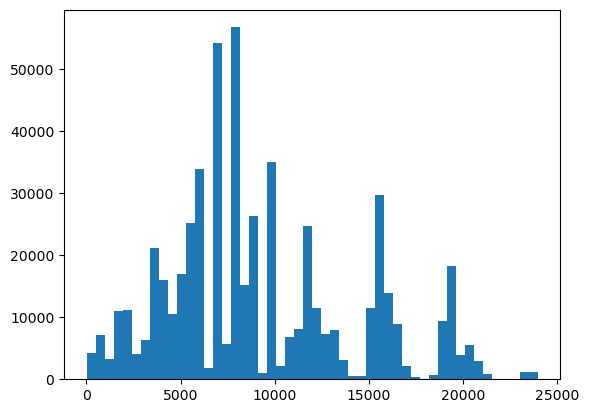

In [26]:
#구매한 제품의 가격대를 분석
plt.hist(df['Purchase'], bins=50)

plt.show()

In [27]:
#구매한 제품의 가격대를 분석


In [28]:
df['Purchase'].describe()

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64

In [31]:
#상위 1% 가격의 구매제품 목록 - 이상치 확인
# df.sort_values(by='Purchase', ascending=False).head(10)
df_cat = df.groupby('Product_Category')['Purchase'].agg(['count', 'mean', 'sum'])
# df_cat = df.sort_values(by='mean', ascending=False)
df_cat.columns = ['Pruchas_count', 'Purchase_Mean', 'Purchase_Sum']
df_cat

,Pruchas_count,Purchase_Mean,Purchase_Sum
Product_Category,,,
1,140378,13606.218596,1910013754
2,23864,11251.935384,268516186
3,20213,10096.705734,204084713
4,11753,2329.659491,27380488
5,150933,6240.088178,941835229
6,20466,15838.478550,324150302
7,3721,16365.689600,60896731
8,113925,7498.958078,854318799
9,410,15537.375610,6370324


In [30]:
df_cat.sort_values(by='Purchase_Mean', ascending=False)

,Pruchas_count,Purchase_Mean,Purchase_Sum
Product_Category,,,
10,5125,19675.570927,100837301
7,3721,16365.689600,60896731
6,20466,15838.478550,324150302
9,410,15537.375610,6370324
15,6290,14780.451828,92969042
16,9828,14766.037037,145120612
1,140378,13606.218596,1910013754
14,1523,13141.625739,20014696
2,23864,11251.935384,268516186


상위 단가 품목 카테고리 : 10, 7, 6, 9, 15, 16

In [17]:
df_cat.sort_values(by='Purchase_Sum', ascending=False)

,Pruchas_count,Purchase_Mean,Purchase_Sum
Product_Category,,,
1,140378,13606.218596,1910013754
5,150933,6240.088178,941835229
8,113925,7498.958078,854318799
6,20466,15838.478550,324150302
2,23864,11251.935384,268516186
3,20213,10096.705734,204084713
16,9828,14766.037037,145120612
11,24287,4685.268456,113791115
10,5125,19675.570927,100837301


상위 매출 품목 카테고리 : 1, 5, 8, 6, 2, 3

<Axes: xlabel='Product_Category'>

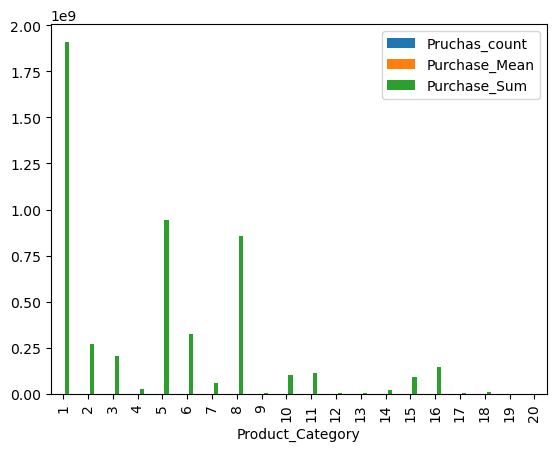

In [ ]:
df_cat['Purchase_Sum']
# df_cat['Purchase_Sum'].plot(kind='bar')

In [13]:
# 고가 전략 제품으로 카테고리 분석
product_cat = df[['Product_Category', 'Purchase']]
product_cat_purchase = df.groupby('Product_Category')['Purchase'].agg(['count', 'sum'])
product_cat_purchase

,count,sum
Product_Category,,
1,140378,1910013754
2,23864,268516186
3,20213,204084713
4,11753,27380488
5,150933,941835229
6,20466,324150302
7,3721,60896731
8,113925,854318799
9,410,6370324


10, 15, 16, 7번 카테고리 순으로 구매가 집중되고 있습니다.<BR>
해당 제품을 확인하여, 고부가가치 상품군이 존재할 가능성을 확인할 필요가 있습니다.<BR>

In [14]:
#저가 제품의 카테고리 집중도
